# Upright Control Experiment Analysis

This notebook loads an `upright_control_*.csv` run, summarizes the logged data, and plots the key signals. It also loads sidecar raw sample logs when they are present.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

# Set this to a specific file, or leave as None to use the newest control CSV.
DATA_PATH = None

candidate_dirs = [
    Path("hardware/control experiments/upright"),
    Path("../upright"),
    Path("hardware/control experiments/upright").resolve(),
    (Path.cwd() / "hardware/control experiments/upright").resolve(),
    (Path.cwd() / "../upright").resolve(),
]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError("Could not locate the upright control data directory from the current notebook working directory.")
if DATA_PATH is None:
    candidates = sorted(
        p for p in data_dir.glob("upright_control_*.csv")
        if "samples" not in p.name
    )
    if not candidates:
        raise FileNotFoundError(f"No upright_control_*.csv files found in {data_dir}")
    path = candidates[-1]
else:
    path = data_dir / DATA_PATH

path

WindowsPath('../upright/upright_control_20260418_181943.csv')

In [14]:
df = pd.read_csv(path)

numeric_columns = [
    "host_elapsed_s", "encoder_time_ms", "theta_deg", "theta_rad", "omega_rad_s",
    "filtered_theta_rad", "filtered_theta_dot_rad_s", "filtered_omega_rad_s",
    "control_x_m", "control_x_dot_m_s", "control_theta_rad", "control_theta_dot_rad_s",
    "raw_count", "unwrapped_count",
    "agc", "magnitude", "actuator_time_ms", "position_steps", "position_mm",
    "command_speed_mm_s", "command_step_rate_s", "command_acceleration_m_s2",
]
if "filtered_theta_dot_rad_s" not in df.columns and "filtered_omega_rad_s" in df.columns:
    df["filtered_theta_dot_rad_s"] = df["filtered_omega_rad_s"]

for column in ["control_x_m", "control_x_dot_m_s", "control_theta_rad", "control_theta_dot_rad_s"]:
    if column not in df.columns:
        df[column] = np.nan

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in ["connected", "magnet_detected", "magnet_too_weak", "magnet_too_strong", "enabled", "left_limit", "right_limit", "any_limit"]:
    if column in df.columns:
        df[column] = df[column].astype(str).map({"True": True, "False": False, "true": True, "false": False})

df.head(), df.tail(), df.shape

(   host_elapsed_s  host_timestamp_s  encoder_time_ms  theta_deg  theta_rad  \
 0           0.000      1.776555e+09           210529     0.0000   0.000000   
 1           0.015      1.776555e+09           210529     0.0000   0.000000   
 2           0.031      1.776555e+09           210549     0.0000   0.000000   
 3           0.031      1.776555e+09           210549     0.0000   0.000000   
 4           0.046      1.776555e+09           210560    -0.3516  -0.006136   
 
    omega_rad_s  filtered_theta_rad  filtered_theta_dot_rad_s  \
 0    -0.153459            0.000000                  0.000000   
 1    -0.153459            0.000000                  0.000000   
 2    -0.153459            0.000000                  0.000000   
 3    -0.153459            0.000000                  0.000000   
 4    -0.613347           -0.002454                 -0.036816   
 
    theta_residual_rad  control_x_m  ...  position_mm  motion_mode  enabled  \
 0            0.000000     0.000038  ...   300.037552

In [15]:
duration_s = df["host_elapsed_s"].iloc[-1] - df["host_elapsed_s"].iloc[0]
stop_reasons = df["stop_reason"].dropna().astype(str)
stop_reasons = stop_reasons[stop_reasons != ""]

summary = {
    "file": str(path),
    "rows": len(df),
    "duration_s": duration_s,
    "stop_reason": stop_reasons.iloc[-1] if len(stop_reasons) else "",
    "theta_deg_min": df["theta_deg"].min(),
    "theta_deg_max": df["theta_deg"].max(),
    "omega_rad_s_min": df["omega_rad_s"].min(),
    "omega_rad_s_max": df["omega_rad_s"].max(),
    "position_mm_min": df["position_mm"].min(),
    "position_mm_max": df["position_mm"].max(),
    "command_speed_min": df["command_speed_mm_s"].min(),
    "command_speed_max": df["command_speed_mm_s"].max(),
    "command_accel_min": df["command_acceleration_m_s2"].min(),
    "command_accel_max": df["command_acceleration_m_s2"].max(),
}

pd.Series(summary)

file                 ..\upright\upright_control_20260418_181943.csv
rows                                                            150
duration_s                                                      1.5
stop_reason                                            angle_cutoff
theta_deg_min                                               -5.5371
theta_deg_max                                               22.7637
omega_rad_s_min                                           -9.813552
omega_rad_s_max                                            11.81638
position_mm_min                                          290.837401
position_mm_max                                          467.423958
command_speed_min                                       -148.024989
command_speed_max                                             500.0
command_accel_min                                              -4.0
command_accel_max                                               4.0
dtype: object

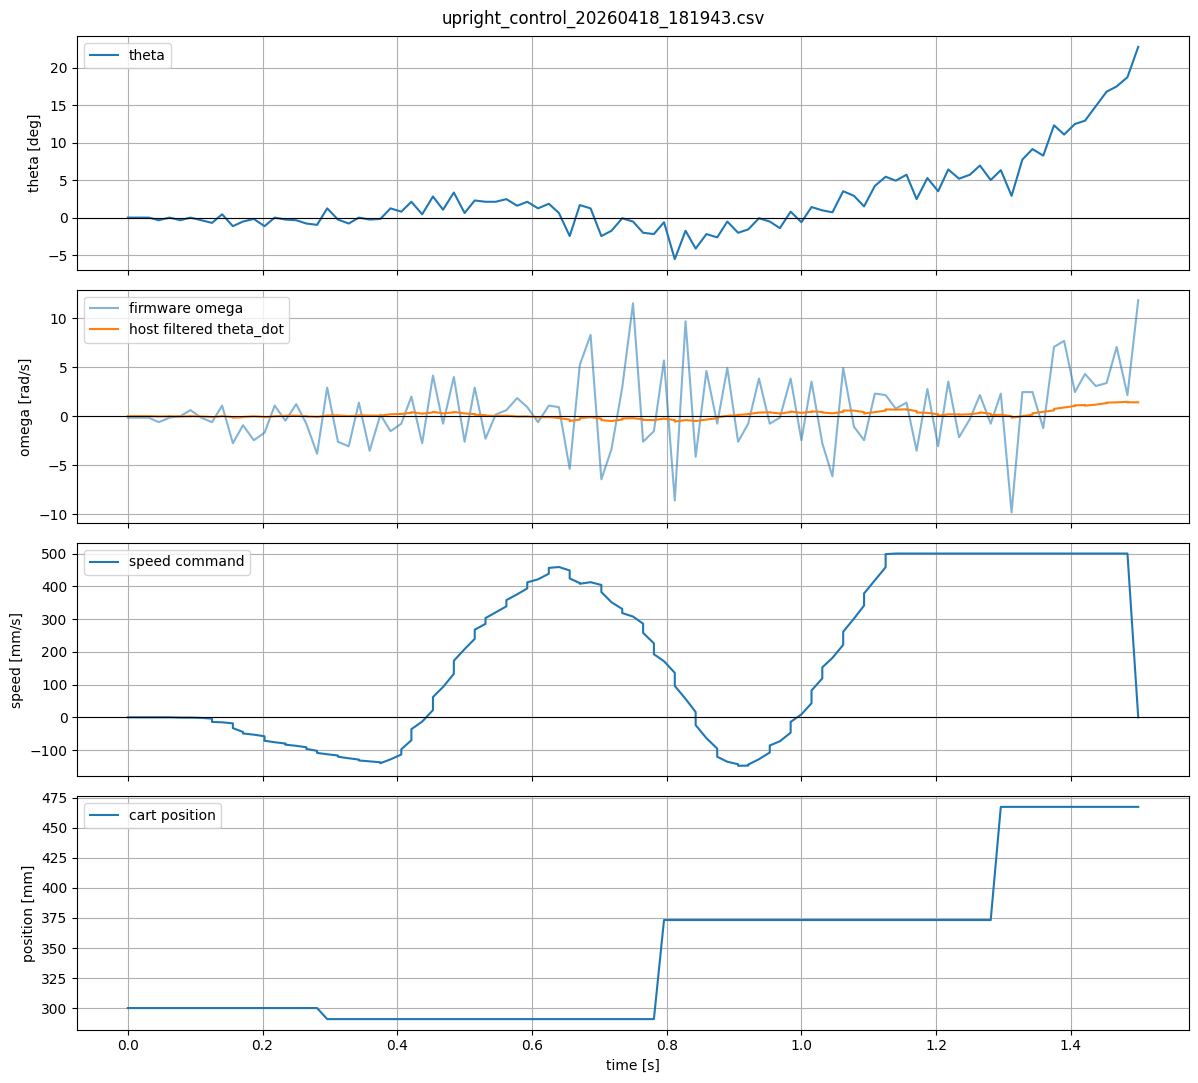

In [16]:
t = df["host_elapsed_s"]

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(t, df["theta_deg"], label="theta")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("theta [deg]")
axes[0].legend()

axes[1].plot(t, df["omega_rad_s"], label="firmware omega", alpha=0.55)
axes[1].plot(t, df["filtered_theta_dot_rad_s"], label="host filtered theta_dot")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("omega [rad/s]")
axes[1].legend()

axes[2].plot(t, df["command_speed_mm_s"], label="speed command")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("speed [mm/s]")
axes[2].legend()

axes[3].plot(t, df["position_mm"], label="cart position")
axes[3].set_ylabel("position [mm]")
axes[3].set_xlabel("time [s]")
axes[3].legend()

fig.suptitle(path.name)
fig.tight_layout()

## Best-Run Overlay

Overlay the current upright run against the best-so-far reference run on the main control signals.

WindowsPath('../upright/upright_control_20260418_161600.csv')

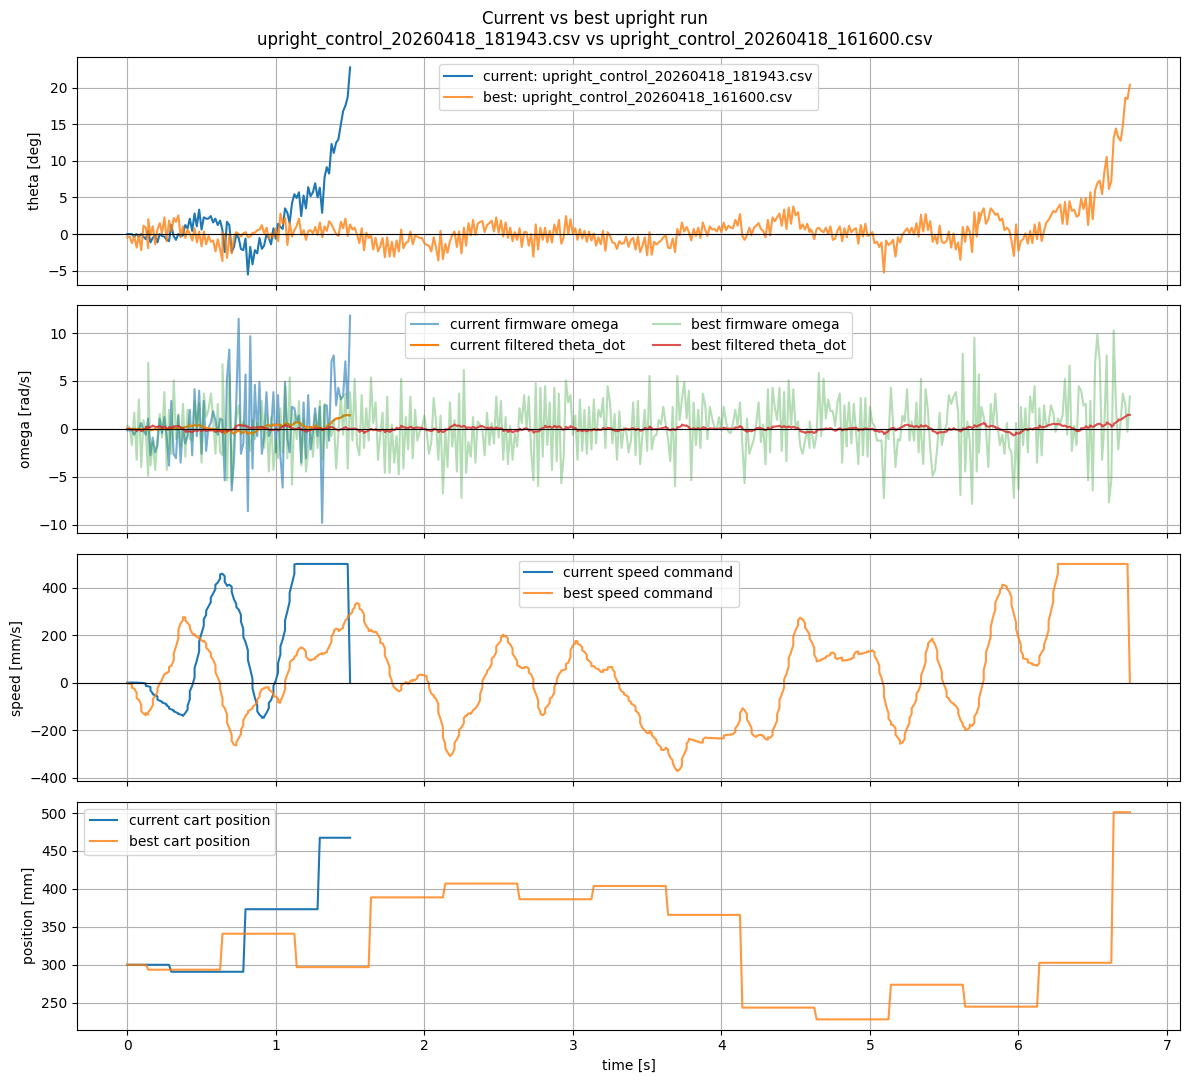

In [17]:
BEST_RUN_PATH = data_dir / "upright_control_20260418_161600.csv"
best_df = pd.read_csv(BEST_RUN_PATH)

if "filtered_theta_dot_rad_s" not in best_df.columns and "filtered_omega_rad_s" in best_df.columns:
    best_df["filtered_theta_dot_rad_s"] = best_df["filtered_omega_rad_s"]

for column in numeric_columns:
    if column in best_df.columns:
        best_df[column] = pd.to_numeric(best_df[column], errors="coerce")

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(df["host_elapsed_s"], df["theta_deg"], label=f"current: {path.name}")
axes[0].plot(best_df["host_elapsed_s"], best_df["theta_deg"], label=f"best: {BEST_RUN_PATH.name}", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("theta [deg]")
axes[0].legend()

axes[1].plot(df["host_elapsed_s"], df["omega_rad_s"], label="current firmware omega", alpha=0.6)
axes[1].plot(df["host_elapsed_s"], df["filtered_theta_dot_rad_s"], label="current filtered theta_dot")
axes[1].plot(best_df["host_elapsed_s"], best_df["omega_rad_s"], label="best firmware omega", alpha=0.35)
axes[1].plot(best_df["host_elapsed_s"], best_df["filtered_theta_dot_rad_s"], label="best filtered theta_dot", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("omega [rad/s]")
axes[1].legend(ncol=2)

axes[2].plot(df["host_elapsed_s"], df["command_speed_mm_s"], label="current speed command")
axes[2].plot(best_df["host_elapsed_s"], best_df["command_speed_mm_s"], label="best speed command", alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("speed [mm/s]")
axes[2].legend()

axes[3].plot(df["host_elapsed_s"], df["position_mm"], label="current cart position")
axes[3].plot(best_df["host_elapsed_s"], best_df["position_mm"], label="best cart position", alpha=0.8)
axes[3].set_ylabel("position [mm]")
axes[3].set_xlabel("time [s]")
axes[3].legend()

fig.suptitle(f"Current vs best upright run\n{path.name} vs {BEST_RUN_PATH.name}")
fig.tight_layout()

BEST_RUN_PATH


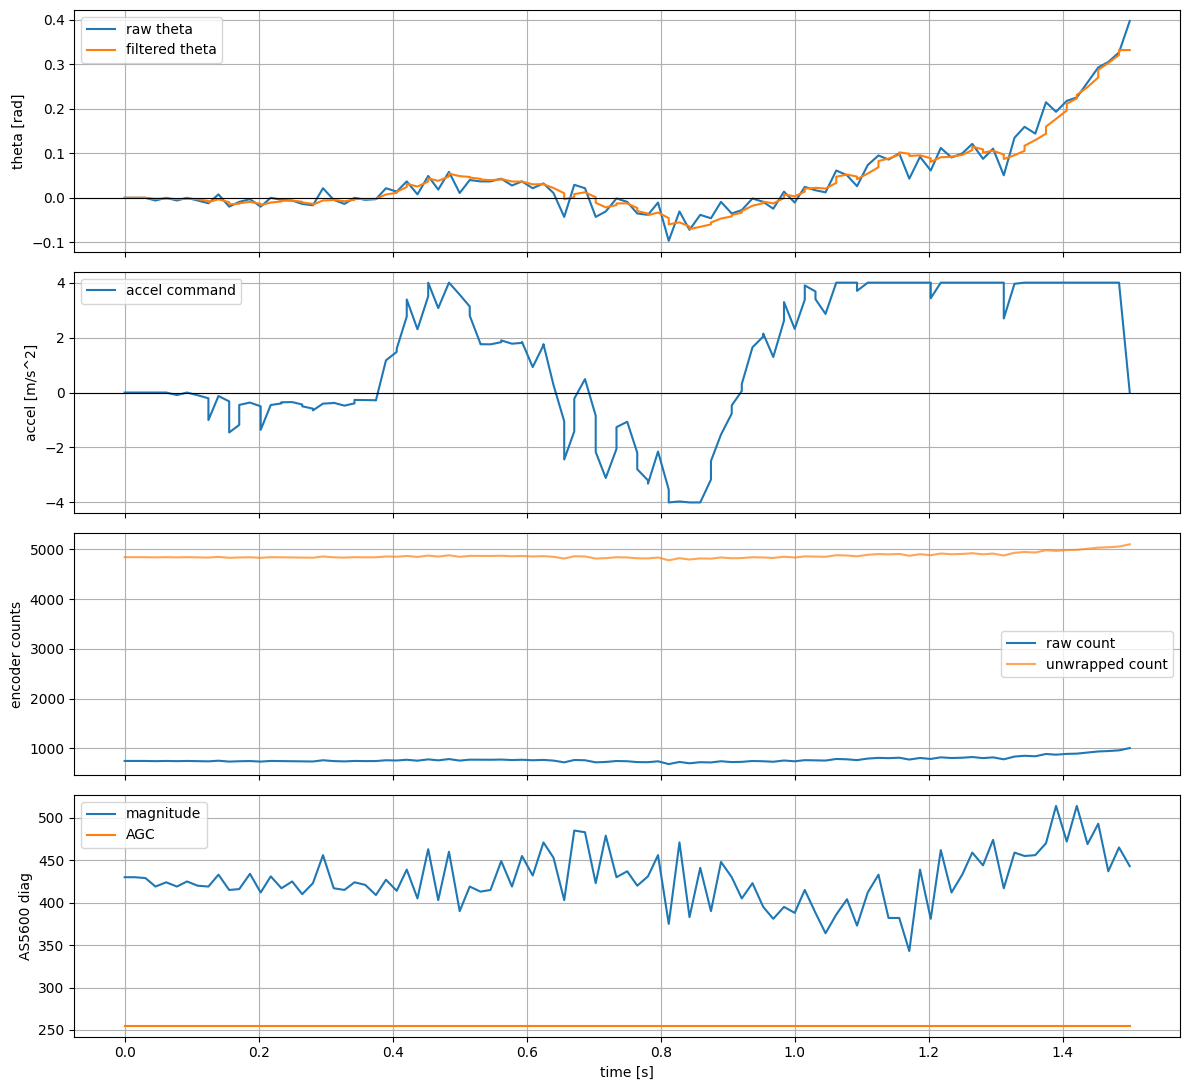

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(t, df["theta_rad"], label="raw theta")
axes[0].plot(t, df["filtered_theta_rad"], label="filtered theta")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("theta [rad]")
axes[0].legend()

axes[1].plot(t, df["command_acceleration_m_s2"], label="accel command")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("accel [m/s^2]")
axes[1].legend()

axes[2].plot(t, df["raw_count"], label="raw count")
axes[2].plot(t, df["unwrapped_count"], label="unwrapped count", alpha=0.7)
axes[2].set_ylabel("encoder counts")
axes[2].legend()

axes[3].plot(t, df["magnitude"], label="magnitude")
axes[3].plot(t, df["agc"], label="AGC")
axes[3].set_ylabel("AS5600 diag")
axes[3].set_xlabel("time [s]")
axes[3].legend()

fig.tight_layout()

In [19]:
deadband_release = df.loc[df["command_speed_mm_s"].abs() > 0, "host_elapsed_s"]
first_active_s = deadband_release.iloc[0] if len(deadband_release) else None
first_active_s

0.078

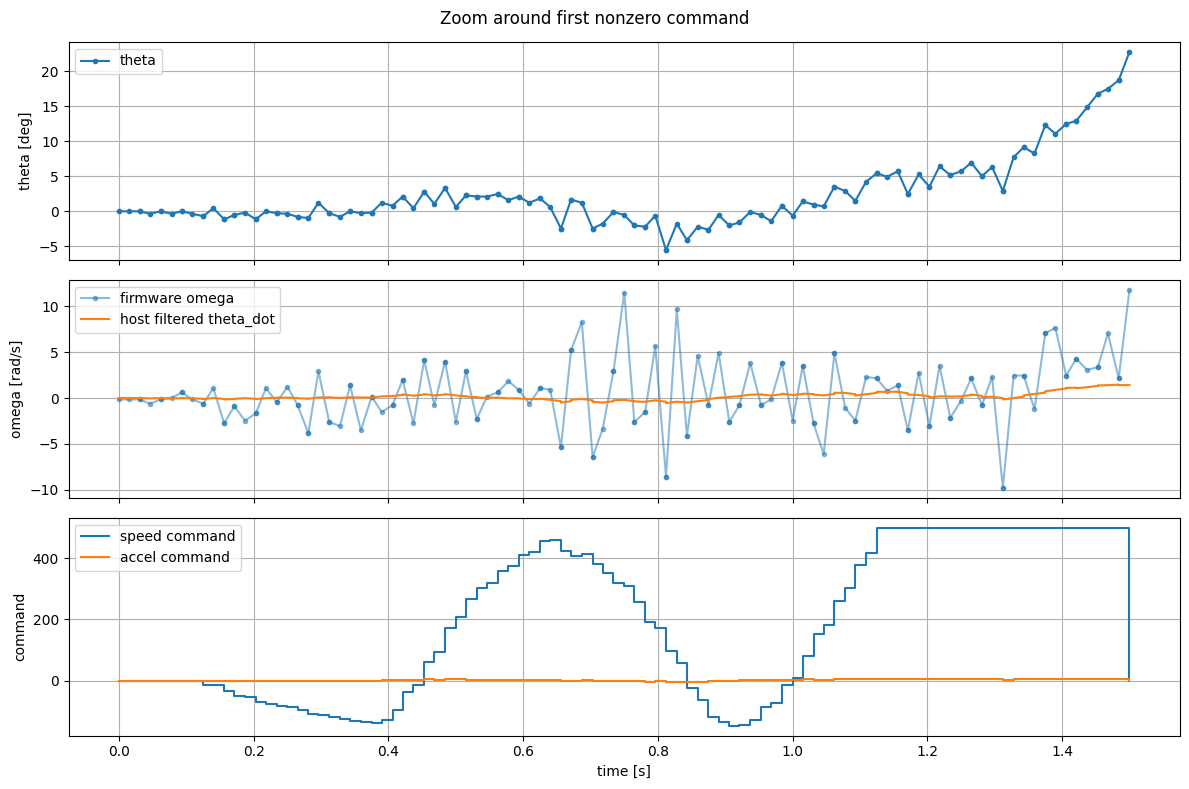

In [20]:
if first_active_s is not None:
    zoom = df[(df["host_elapsed_s"] >= first_active_s - 1.0) & (df["host_elapsed_s"] <= first_active_s + 5.0)]
else:
    zoom = df

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
zt = zoom["host_elapsed_s"]

axes[0].plot(zt, zoom["theta_deg"], marker=".", label="theta")
axes[0].set_ylabel("theta [deg]")
axes[0].legend()

axes[1].plot(zt, zoom["omega_rad_s"], marker=".", alpha=0.5, label="firmware omega")
axes[1].plot(zt, zoom["filtered_theta_dot_rad_s"], label="host filtered theta_dot")
axes[1].set_ylabel("omega [rad/s]")
axes[1].legend()

axes[2].step(zt, zoom["command_speed_mm_s"], where="post", label="speed command")
axes[2].step(zt, zoom["command_acceleration_m_s2"], where="post", label="accel command")
axes[2].set_ylabel("command")
axes[2].set_xlabel("time [s]")
axes[2].legend()

fig.suptitle("Zoom around first nonzero command")
fig.tight_layout()

In [21]:
sat_speed = (df["command_speed_mm_s"].abs() >= df["command_speed_mm_s"].abs().max() - 1e-9).mean()
sat_accel = (df["command_acceleration_m_s2"].abs() >= df["command_acceleration_m_s2"].abs().max() - 1e-9).mean()

command_sign = np.sign(df["command_speed_mm_s"].to_numpy())
nonzero_sign = command_sign[command_sign != 0]
sign_flips = int(np.sum(nonzero_sign[1:] != nonzero_sign[:-1])) if len(nonzero_sign) > 1 else 0

pd.Series({
    "fraction_at_speed_limit": sat_speed,
    "fraction_at_accel_limit": sat_accel,
    "command_sign_flips": sign_flips,
    "first_nonzero_command_s": first_active_s,
})

fraction_at_speed_limit    0.240000
fraction_at_accel_limit    0.313333
command_sign_flips         3.000000
first_nonzero_command_s    0.078000
dtype: float64

In [22]:
sidecars = {
    "encoder": path.with_name(f"{path.stem}_encoder_samples.csv"),
    "actuator": path.with_name(f"{path.stem}_actuator_samples.csv"),
    "limits": path.with_name(f"{path.stem}_limit_samples.csv"),
}

loaded_sidecars = {}
for name, sidecar_path in sidecars.items():
    if sidecar_path.exists():
        loaded_sidecars[name] = pd.read_csv(sidecar_path)
        print(name, sidecar_path.name, loaded_sidecars[name].shape)
    else:
        print(name, "missing", sidecar_path.name)

encoder upright_control_20260418_181943_encoder_samples.csv (149, 14)
actuator upright_control_20260418_181943_actuator_samples.csv (3, 9)
limits upright_control_20260418_181943_limit_samples.csv (75, 11)


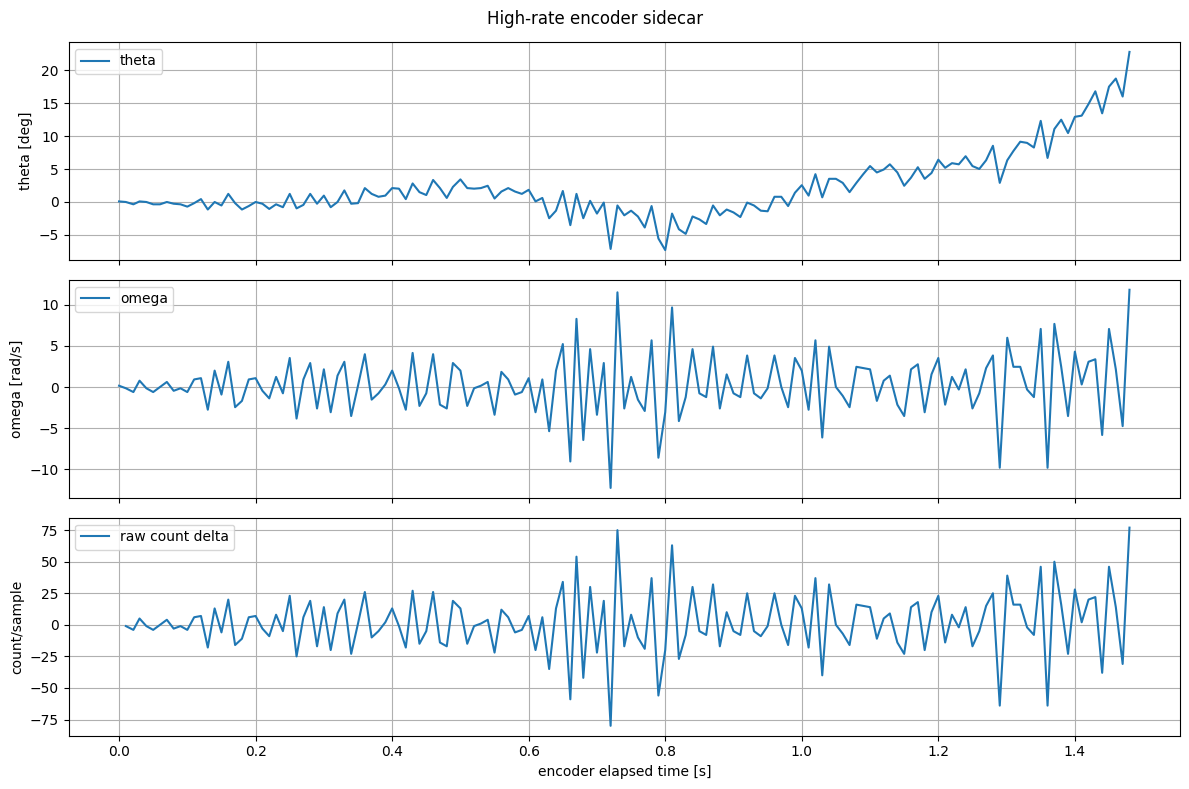

In [23]:
encoder_samples = loaded_sidecars.get("encoder")
if encoder_samples is not None:
    for column in ["host_timestamp_s", "time_ms", "theta_deg", "theta_rad", "omega_rad_s", "raw_count", "magnitude", "agc"]:
        if column in encoder_samples.columns:
            encoder_samples[column] = pd.to_numeric(encoder_samples[column], errors="coerce")

    encoder_samples["elapsed_s"] = (encoder_samples["time_ms"] - encoder_samples["time_ms"].iloc[0]) / 1000.0
    encoder_samples["raw_count_delta"] = encoder_samples["raw_count"].diff()

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    et = encoder_samples["elapsed_s"]
    axes[0].plot(et, encoder_samples["theta_deg"], label="theta")
    axes[0].set_ylabel("theta [deg]")
    axes[0].legend()
    axes[1].plot(et, encoder_samples["omega_rad_s"], label="omega")
    axes[1].set_ylabel("omega [rad/s]")
    axes[1].legend()
    axes[2].plot(et, encoder_samples["raw_count_delta"], label="raw count delta")
    axes[2].set_ylabel("count/sample")
    axes[2].set_xlabel("encoder elapsed time [s]")
    axes[2].legend()
    fig.suptitle("High-rate encoder sidecar")
    fig.tight_layout()
else:
    print("No encoder sidecar log found.")

In [24]:
if encoder_samples is not None:
    encoder_samples["abs_raw_jump"] = encoder_samples["raw_count_delta"].abs()
    encoder_samples.nlargest(20, "abs_raw_jump")[["elapsed_s", "theta_deg", "omega_rad_s", "raw_count", "raw_count_delta", "magnitude", "agc"]]